# 3. Generate SHAP Explanations

Compute SHAP values for understanding model decisions.

In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt

# Load model, data, and scaler
with open('../data/model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../data/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../data/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Load original data
df = pd.read_csv('../data/creditcard.csv')
X = df.drop('Class', axis=1).values
X_scaled = scaler.transform(X)

print(f"Data shape: {X_scaled.shape}")
print(f"Feature names: {feature_names[:5]}...")

Data shape: (284807, 30)
Feature names: ['Time', 'V1', 'V2', 'V3', 'V4']...


## Compute SHAP Values

In [2]:
# Use SHAP TreeExplainer for XGBoost
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(model)

# Compute SHAP values (this may take a minute for large datasets)
print("Computing SHAP values... (this may take a few moments)")
shap_values = explainer.shap_values(X_scaled)

# For binary classification, shap_values is usually a list [shap_class0, shap_class1]
# Use values for the positive class (fraud)
if isinstance(shap_values, list):
    shap_values_fraud = shap_values[1]
else:
    shap_values_fraud = shap_values

print(f"SHAP values shape: {shap_values_fraud.shape}")
print(f"Sample SHAP values (first 5 features): {shap_values_fraud[0, :5]}")

Creating SHAP explainer...
Computing SHAP values... (this may take a few moments)


SHAP values shape: (284807, 30)
Sample SHAP values (first 5 features): [-0.12302122  0.05470096  0.0833267  -1.0049677   0.44662672]


## Save SHAP Values

In [3]:
# Save for later use
np.save('../data/shap_values.npy', shap_values_fraud)
print("SHAP values saved!")

SHAP values saved!


## Visualize Feature Importance (Global)

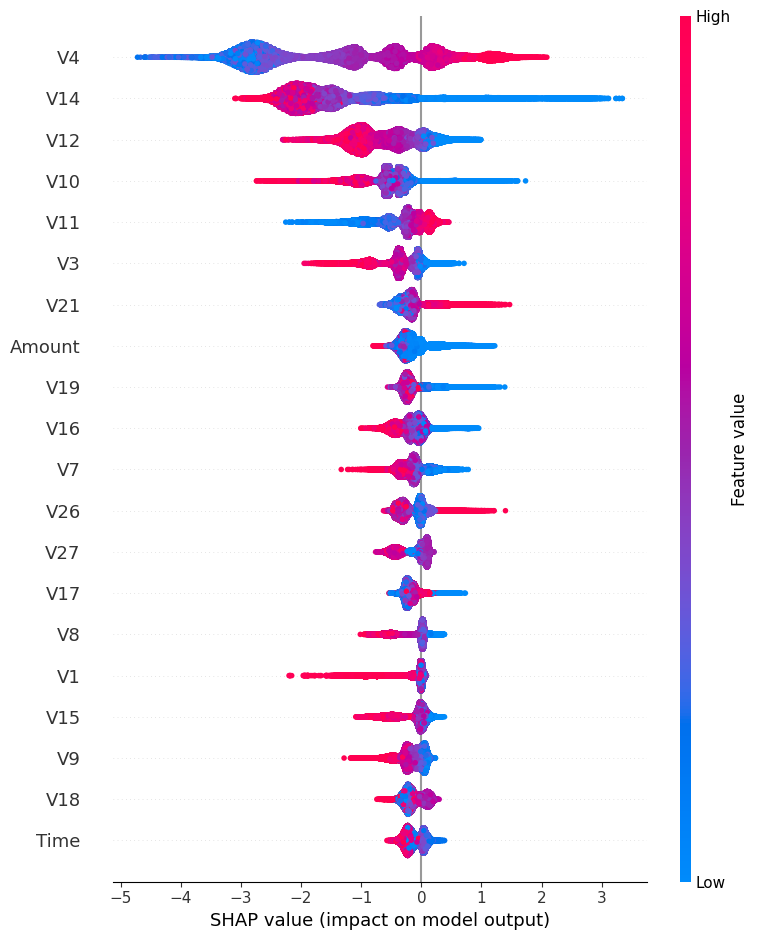

Summary plot saved!


In [4]:
# Summary plot: global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_fraud, X_scaled, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print("Summary plot saved!")

## Visualize Sample Explanations (Local)

Fraud sample index: 541
Legitimate sample index: 0


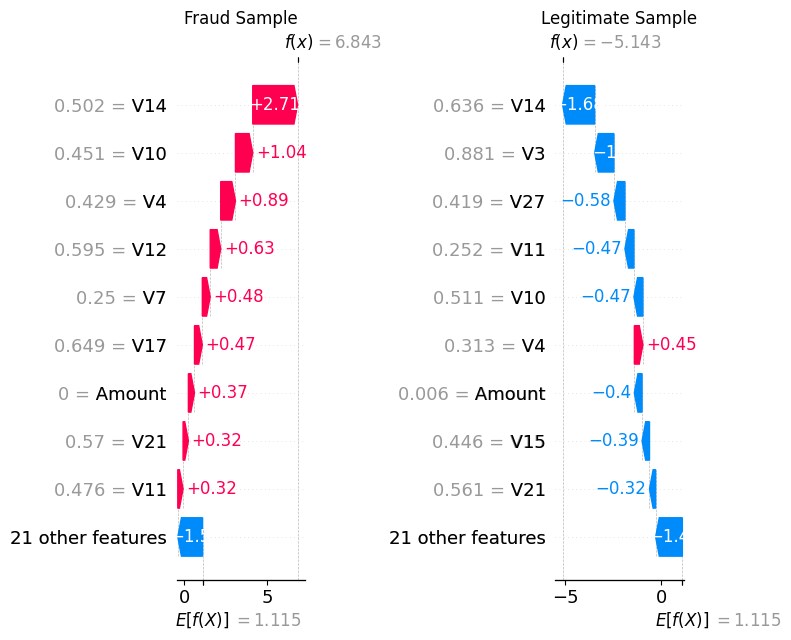

Waterfall plots saved!


In [5]:
# Find a fraud sample and a legitimate sample
y = df['Class'].values
y_scaled = df['Class'].values

fraud_idx = np.where(y_scaled == 1)[0][0]
legit_idx = np.where(y_scaled == 0)[0][0]

print(f"Fraud sample index: {fraud_idx}")
print(f"Legitimate sample index: {legit_idx}")

# Plot explanations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, title in [(fraud_idx, 'Fraud Sample'), (legit_idx, 'Legitimate Sample')]:
    plt.subplot(1, 2, 1 if idx == fraud_idx else 2)
    shap.waterfall_plot(shap.Explanation(
        values=shap_values_fraud[idx],
        base_values=explainer.expected_value,
        data=X_scaled[idx],
        feature_names=feature_names
    ), show=False)
    plt.title(title)

plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=100, bbox_inches='tight')
plt.show()

print("Waterfall plots saved!")